In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

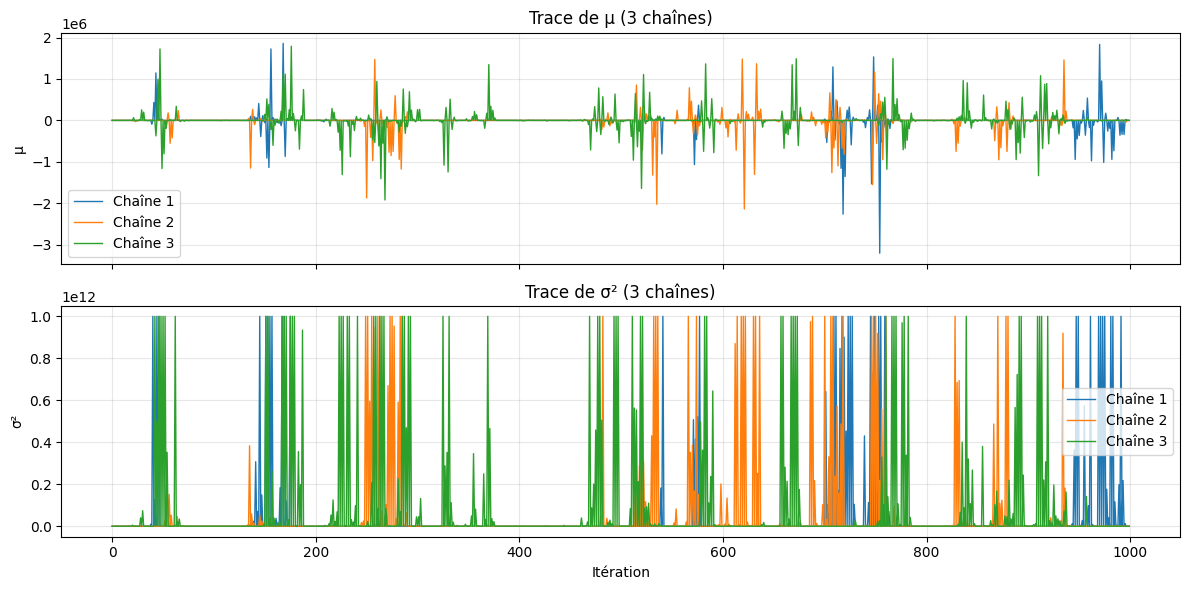

In [12]:
n_chains = 3
n_iter = 1000
eps = 1e-12

chains = np.empty((n_chains, n_iter, 3), dtype=float)  # (chain, iter, [X, mu, sigma2])
X = np.random.normal(0, np.sqrt(1))

for c in range(n_chains):
    mu, sigma2 = 0.0, 1.0  # (re)initialize each chain

    for t in range(n_iter):
        sigma2 = max(float(sigma2), eps)

        mu = np.random.normal(X, np.sqrt(sigma2))

        scale = max((X - mu) ** 2 / 2, eps)
        g = np.random.gamma(shape=0.5, scale=scale)
        g = max(float(g), eps)
        sigma2 = 1.0 / g

        chains[c, t] = (X, mu, sigma2)

iters = np.arange(n_iter)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for c in range(n_chains):
    ax[0].plot(iters, chains[c, :, 1], lw=1, label=f"Chaîne {c+1}")
ax[0].set_title("Trace de μ (3 chaînes)")
ax[0].set_ylabel("μ")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

for c in range(n_chains):
    ax[1].plot(iters, chains[c, :, 2], lw=1, label=f"Chaîne {c+1}")
ax[1].set_title("Trace de σ² (3 chaînes)")
ax[1].set_xlabel("Itération")
ax[1].set_ylabel("σ²")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


problème, c'est pas intégrable donc ca ne converge pas 

Gibbs pour une normale tronquée 

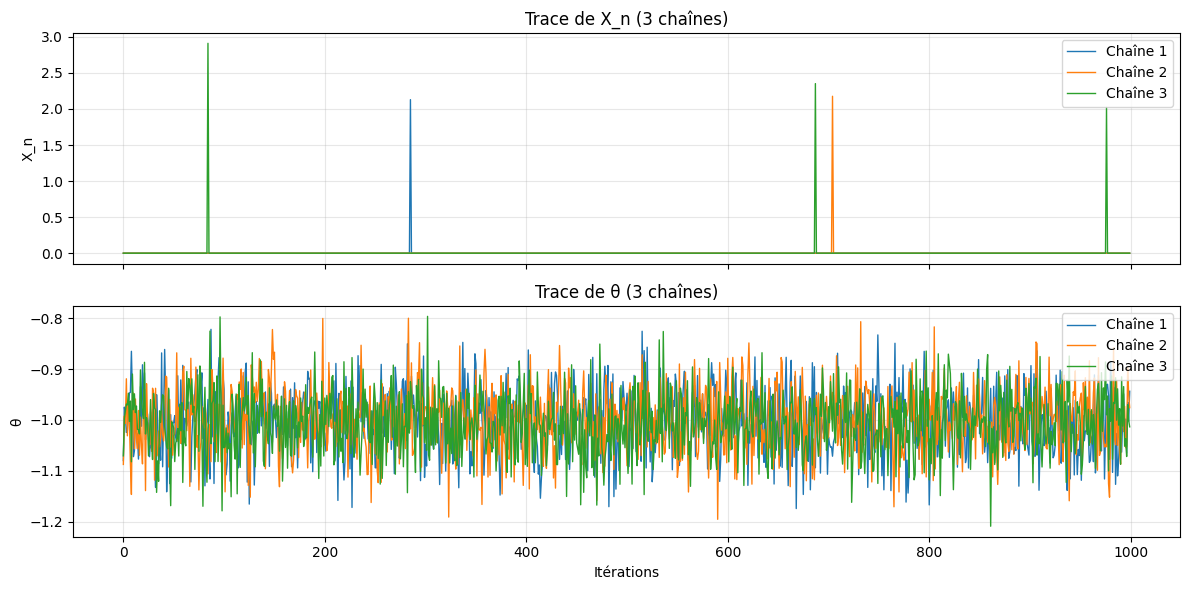

In [19]:
# gibbs pour une normale tronquée 

theta_0 = 0.0
y = 2
n = 15
mu = 0.0
X = np.random.normal(theta_0, n)

n_chains = 3
n_iter = 1000
eps = 1e-12

chains = np.empty((n_chains, n_iter, 2), dtype=float)  # (chain, iter, [X, theta])

for c in range(n_chains):
    theta = 0.0  # (re)initialize each chain

    for t in range(n_iter):
        theta = np.random.normal(1/n * (mu + np.sum(X)), 1/(n+1))

        X_n = np.random.normal(theta, 1)
        if X_n <= y:
            X_n = 0

        chains[c, t] = (X_n, theta)

iters = np.arange(n_iter)
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for c in range(n_chains):
    ax[0].plot(iters, chains[c, :, 0], lw=1, label=f"Chaîne {c+1}")
ax[0].set_title("Trace de X_n (3 chaînes)")
ax[0].set_ylabel("X_n")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

for c in range(n_chains):
    ax[1].plot(iters, chains[c, :, 1], lw=1, label=f"Chaîne {c+1}")

ax[1].set_title("Trace de θ (3 chaînes)")
ax[1].set_ylabel("θ")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.xlabel("Itérations")
plt.tight_layout()
plt.show()